In [2]:
print("Hello")

Hello


In [1]:
!pip install great_tables
import pandas as pd
from great_tables import GT

data = pd.read_csv("https://minio.lab.sspcloud.fr/matteo/data-es.csv", sep=";")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 21.0 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 23.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [great_tables] [great_tables]


/tmp/ipykernel_5543/1432933043.py:5: DtypeWarning: Columns (6,8,19,23,25,29) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("https://minio.lab.sspcloud.fr/matteo/data-es.csv", sep=";")


In [2]:
data.columns
for col in data.columns:
    print(col)

equip_numero
inst_numero
inst_enqu_date
inst_nom
inst_siret
inst_adresse
inst_cp
new_name
new_code
inst_part_type_filter
inst_uai
inst_acc_handi_type
inst_trans_type
inst_obs
inst_date_etat
inst_date_creation
inst_hs_bool
epci_code
epci_nom
dep_code
dep_nom
reg_code
reg_nom
code_bdv
lib_bdv
arr_code
arr_name
dens_niveau
dens_lib
dep_code_filled
aca_nom
zrr_simp
equip_nom
equip_type_name
equip_coordonnees
equip_prop_nom
equip_prop_type
equip_propsec_type
equip_gest_type
equip_cogest_type
equip_dsp
equip_ouv_public_bool
equip_erp_type
equip_erp_cat
equip_homo_date
equip_homo_periode
equip_service_date
equip_service_periode
equip_travaux_date
equip_travaux_periode
equip_travaux_type
equip_energie
equip_nature
equip_sol
equip_long
equip_larg
equip_haut
equip_surf
equip_eclair
equip_piste_nb
equip_trib_nb
equip_vest_sport
equip_vest_ens
equip_douche
equip_sanit
equip_loc_type
equip_conf_type
equip_acces_handi_mobilite
equip_acces_handi_sensoriel
equip_pdesi_pdipr
equip_bassin_long
equip_bas

In [3]:
pd.unique(data['equip_type_famille'])

array(['Salle multisports', 'Court de tennis',
       'Terrain extérieur de petits jeux collectifs',
       "Equipement d'activités de forme et de santé",
       'Equipement de cyclisme', 'Salle de combat',
       'Divers équipements Sports de nature', 'Multisports/City-stades',
       'Boulodrome', 'Salle ou terrain spécialisé',
       'Terrain de grands jeux', 'Skatepark & vélo Freestyle',
       'Pas de tir', "Equipement d'athlétisme", 'Parcours sportif/santé',
       'Salle non spécialisée', 'Parcours de golf', 'Mur et fronton',
       'Bowling', "Site d'activités aquatiques et nautiques",
       'Bassin de natation', 'Equipement équestre',
       'Circuit/piste de sports mécaniques',
       "Structure Artificielle d'Escalade", "Site d'activités aériennes",
       'Site de modélisme', 'Aire de sports de glaces',
       'Equipement & piste de ski', 'Divers équipements', nan],
      dtype=object)

In [4]:
data['equip_type_famille'].str.lower().str.contains("site d'activités aquatiques et nautiques").sum()

11594

In [5]:

data_nautique = data[data['equip_type_famille'] == "Site d'activités aquatiques et nautiques"]


colonnes = ['equip_numero', "inst_numero", "inst_nom", "inst_adresse", "inst_cp", "dep_code", "reg_code", "dep_nom", "reg_nom", "lib_bdv", "equip_nom", "equip_type_name", "equip_coordonnees", "aps_name"]
data_nautique = data_nautique[colonnes].reset_index(drop=True).copy()



In [6]:
data_sud = data_nautique[data_nautique['dep_code'].str.lower().isin(["13", "6"])]
data_sud['aps_name'].str.lower().str.contains("surf|ski|voile|foil|wake").sum()

99

In [7]:
mots = ["surf", "ski", "voile", "foil", "wake"]
pattern = "|".join(mots)
data_nautique = data_nautique[data_nautique['aps_name'].str.contains(pattern, case=False, na=False)]
data_nautique['dep_code'] = data_nautique['dep_code'].astype(str)
data_nautique

,equip_numero,inst_numero,inst_nom,inst_adresse,inst_cp,dep_code,reg_code,dep_nom,reg_nom,lib_bdv,equip_nom,equip_type_name,equip_coordonnees,aps_name
4,E003I974130041,I974130041,Baie de St Leu,rue de la Campagnie des Indes,97416,974,4.0,La Réunion,La Réunion,Saint-Leu,La Cafrine,Site d'activités aquatiques et nautiques,"-21.1867, 55.2866",Surf
5,E003I974130046,I974130046,Cimetière de St Leu,RN 1 Grand Fond,97416,974,4.0,La Réunion,La Réunion,Saint-Leu,Le cimetière,Site d'activités aquatiques et nautiques,"-21.1858, 55.287",Surf
8,E001I690640001,I690640001,BASE DE LOISIRS DE CONDRIEU,LA PRESQU'ILE,69420,69,84.0,Rhône,Auvergne-Rhône-Alpes,Condrieu,Base de loisirs-plan d'eau,Site d'activités aquatiques et nautiques,"45.45552, 4.77446","Canoë de randonnée,Téléski nautique"
15,E004I011840003,I011840003,CHAMBOD - CENTRE UDPA,NaN,1250,1,84.0,Ain,Auvergne-Rhône-Alpes,Ceyzériat,SITE MIXTE,Site d'activités aquatiques et nautiques,"46.12417, 5.42917","Baignade loisirs,Canoë de randonnée,Kayak-polo..."
17,E005I412690005,I412690005,COMPLEXE SPORTIF DES GRANDS PRES,Rue Geoffroy Martel,41100,41,24.0,Loir-et-Cher,Centre-Val de Loire,Vendôme,Base nautique des Grands Prés,Site d'activités aquatiques et nautiques,"47.79099, 1.0741","Canoë de randonnée,Planche à Voile"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11570,E006I581800003,I581800003,Base Nautique des Settons,Lac des Settons D 193 Montsauche les settons,58230,58,27.0,Nièvre,Bourgogne-Franche-Comté,Saulieu,Base de plein air multiactivités,Site d'activités aquatiques et nautiques,"47.18739, 4.0643","Aviron,Canoë de randonnée,Dériveur / Multicoqu..."
11576,E006I721820001,I721820001,Espace touristique du lac de Mansigné,Route de Plessis,72510,72,52.0,Sarthe,Pays de la Loire,Écommoy,Plan d'eau,Site de pêche,"47.75788, 0.13017",Dériveur / Multicoques / Courses océaniques / ...
11583,E004I880820003,I880820003,Pôle sports nature,La grande haie,88110,88,44.0,Vosges,Grand Est,Raon-l'Étape,Site d'activités aquatiques,Site d'activités aquatiques et nautiques,"48.4565, 6.95106","Baignade loisirs,Canoë de randonnée,Planche à ..."
11585,E004I890240043,I890240043,Base nautique de VAUX,22 Rue du poiry Vaux,89000,89,27.0,Yonne,Bourgogne-Franche-Comté,Auxerre,Base de ski nautique - Rte de Poiry,Stade de ski nautique,"47.76078, 3.59631",Ski nautique classique / Course / à figures li...


In [8]:
import geopandas as gpd
from shapely.geometry import Point

# Séparer lat/lon (si equip_coordonnees est du type "lat, lon")
data_nautique[['lat', 'lon']] = data_nautique['equip_coordonnees'].str.split(',', expand=True).astype(float)

data_nautique['lat'] = data_nautique['lat'].dropna()
data_nautique['lon'] = data_nautique['lon'].dropna()
data_nautique['equip_nom'] = data_nautique['equip_nom'].dropna()
# Créer le GeoDataFrame
geometry = [Point(lon, lat) for lat, lon in zip(data_nautique['lat'], data_nautique['lon'])]
gdf = gpd.GeoDataFrame(data_nautique, geometry=geometry, crs=2154)

In [9]:
!pip install folium

import folium
m = folium.Map(location=[46.6, 2.3], zoom_start=6)

for _, row in data_nautique.dropna(subset=['lat', 'lon']).iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=row['aps_name']
    ).add_to(m)

#m


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [folium]


In [10]:
# Nombre d'équipements par département
tab_dep = (
    data_nautique
    .groupby('dep_nom')
    .size()
    .reset_index(name='nb_equipements')
)
tab_dep

,dep_nom,nb_equipements
0,Ain,21
1,Aisne,11
2,Allier,5
3,Alpes-Maritimes,75
4,Alpes-de-Haute-Provence,8
...,...,...
101,Vienne,6
102,Vosges,4
103,Wallis-et-Futuna,2
104,Yonne,10


In [11]:
# Top 3
top3 = tab_dep.nlargest(3, 'nb_equipements')

# Bottom 3
bottom3 = tab_dep.nsmallest(3, 'nb_equipements')

# Combiner
tab_final = pd.concat([top3, bottom3])

# Ajouter une colonne pour distinguer
tab_final['categorie'] = ['Top 3'] * 3 + ['Les 3 moins bons'] * 3

tab_final = tab_final.sort_values(
    by=['categorie', 'nb_equipements'],
    ascending=[False, False]
)

tab_final = tab_final.reset_index(drop=True)

tab_final

,dep_nom,nb_equipements,categorie
0,Morbihan,359,Top 3
1,Finistère,279,Top 3
2,Côtes-d'Armor,221,Top 3
3,Haute-Loire,1,Les 3 moins bons
4,Hautes-Pyrénées,1,Les 3 moins bons
5,Saint-Barthélemy,1,Les 3 moins bons


In [12]:
from great_tables import GT

table = (
    GT(tab_final)
    .tab_header(
        title="Départements les plus et moins équipés d'équipements nautiques)",
        subtitle="Top 3 et Bottom 3 en nombre d'équipements"
    )
    .cols_label(
        dep_nom="Nom du département",
        nb_equipements="Nombre d'équipements",
        categorie="Catégorie"
    )
    .fmt_number(columns=['nb_equipements'], decimals=0)
    .data_color(
        columns=['nb_equipements'],
        palette=["lightblue", "darkblue"]
    )
)

table

GT(_tbl_data=            dep_nom  nb_equipements         categorie
0          Morbihan             359             Top 3
1         Finistère             279             Top 3
2     Côtes-d'Armor             221             Top 3
3       Haute-Loire               1  Les 3 moins bons
4   Hautes-Pyrénées               1  Les 3 moins bons
5  Saint-Barthélemy               1  Les 3 moins bons, _body=<great_tables._gt_data.Body object at 0x7f845e830980>, _boxhead=Boxhead([ColInfo(var='dep_nom', type=<ColInfoTypeEnum.default: 1>, column_label='Nom du département', column_align='left', column_width=None), ColInfo(var='nb_equipements', type=<ColInfoTypeEnum.default: 1>, column_label="Nombre d'équipements", column_align='right', column_width=None), ColInfo(var='categorie', type=<ColInfoTypeEnum.default: 1>, column_label='Catégorie', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f845e8306e0>, _spanners=Spanners([]), _heading=Heading(title="Départements les plus et moins équipés d'équipements nautiques)", subtitle="Top 3 et Bottom 3 en nombre d'équipements", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f845e830d70>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f845ea81590>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='nb_equipements', rows=[0], mask=None), grpname=None, colname='nb_equipements', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#00008b')]), StyleInfo(locname=LocBody(columns='nb_equipements', rows=[1], mask=None), grpname=None, colname='nb_equipements', rownum=1, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#27309f')]), StyleInfo(locname=LocBody(columns='nb_equipements', rows=[2], mask=None), grpname=None, colname='nb_equipements', rownum=2, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#4353ae')]), StyleInfo(locname=LocBody(columns='nb_equipements', rows=[3], mask=None), grpname=None, colname='nb_equipements', rownum=3, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#add8e6')]), StyleInfo(locname=LocBody(columns='nb_equipements', rows=[4], mask=None), grpname=None, colname='nb_equipements', rownum=4, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#add8e6')]), StyleInfo(locname=LocBody(columns='nb_equipements', rows=[5], mask=None), grpname=None, colname='nb_equipements', rownum=5, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#add8e6')])], _locale=<great_tables._gt_data.Locale object at 0x7f845e830ec0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f845e830c20>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', v

# Création de la table mêlant département et catégories de sports nautiques 

In [13]:
table_dep =(
    data
    .groupby(['dep_nom', 'equip_type_famille'])
    .size()
    .unstack(fill_value=0)
)

table_dep.head()

equip_type_famille,Aire de sports de glaces,Bassin de natation,Boulodrome,Bowling,Circuit/piste de sports mécaniques,Court de tennis,Divers équipements,Divers équipements Sports de nature,Equipement & piste de ski,Equipement d'activités de forme et de santé,...,Salle multisports,Salle non spécialisée,Salle ou terrain spécialisé,Site d'activités aquatiques et nautiques,Site d'activités aériennes,Site de modélisme,Skatepark & vélo Freestyle,Structure Artificielle d'Escalade,Terrain de grands jeux,Terrain extérieur de petits jeux collectifs
dep_nom,,,,,,,,,,,,,,,,,,,,,
Ain,1,61,504,2,23,492,3,469,16,85,...,180,235,122,85,57,5,58,37,552,158
Aisne,3,47,624,6,19,293,1,181,0,76,...,153,236,90,256,8,4,27,22,544,162
Allier,1,46,214,4,13,254,0,372,3,62,...,112,172,91,42,9,7,20,20,399,105
Alpes-Maritimes,3,83,436,0,4,586,1,504,27,206,...,158,78,162,201,33,5,28,44,229,124
Alpes-de-Haute-Provence,2,43,70,1,16,168,0,691,12,18,...,29,71,34,51,51,1,14,20,106,51


# ACP sur la BDD complète (pas seulement les équipements nautiques car pas de résultats concluants)


## Normalisation pour éviter que des départements prennent toute l'explication


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
table_norm = scaler.fit_transform(table_dep)
table_norm = table_dep.div(table_dep.sum(axis=1), axis=0)

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(table_norm)

# Dataframe des résultats
df_pca = pd.DataFrame(coords, columns=['PC1', 'PC2'])
df_pca['dep_nom'] = table_dep.index

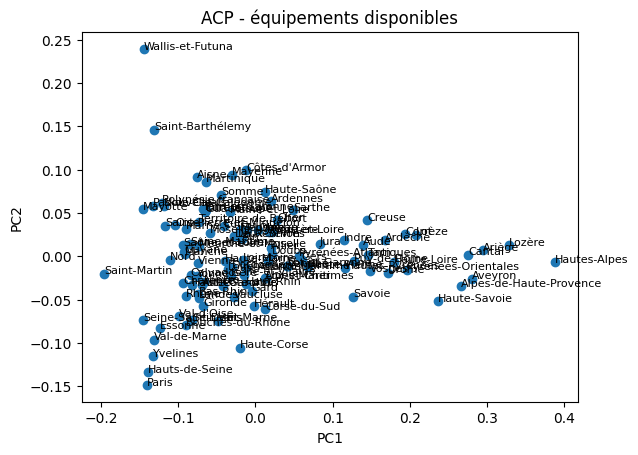

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_pca['PC1'], df_pca['PC2'])

for i, dep in enumerate(df_pca['dep_nom']):
    plt.text(df_pca['PC1'][i], df_pca['PC2'][i], dep, fontsize=8)

plt.title("ACP - équipements disponibles")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=0)
clusters = kmeans.fit_predict(table_norm)

table_dep['cluster'] = clusters
df_pca['cluster'] = clusters

In [18]:
cluster_profile = table_dep.groupby('cluster').mean()
cluster_profile

equip_type_famille,Aire de sports de glaces,Bassin de natation,Boulodrome,Bowling,Circuit/piste de sports mécaniques,Court de tennis,Divers équipements,Divers équipements Sports de nature,Equipement & piste de ski,Equipement d'activités de forme et de santé,...,Salle multisports,Salle non spécialisée,Salle ou terrain spécialisé,Site d'activités aquatiques et nautiques,Site d'activités aériennes,Site de modélisme,Skatepark & vélo Freestyle,Structure Artificielle d'Escalade,Terrain de grands jeux,Terrain extérieur de petits jeux collectifs
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.375000,60.531250,317.062500,2.593750,16.125000,365.437500,3.906250,288.765625,3.250000,123.187500,...,186.375000,168.140625,143.718750,114.109375,18.734375,6.609375,36.234375,27.390625,457.203125,145.843750
1,3.333333,50.333333,164.000000,2.000000,11.777778,229.555556,1.000000,1036.111111,27.777778,64.333333,...,68.222222,90.333333,66.666667,116.444444,58.666667,4.000000,26.555556,24.777778,180.555556,63.333333
2,0.000000,9.750000,30.000000,0.000000,2.500000,49.500000,0.000000,21.250000,0.000000,19.250000,...,29.000000,17.000000,21.750000,65.000000,6.000000,0.000000,3.750000,4.750000,105.000000,50.750000
3,1.947368,54.105263,235.105263,2.894737,17.052632,271.052632,2.473684,672.315789,12.684211,92.210526,...,123.894737,126.842105,100.052632,125.842105,33.000000,4.473684,28.315789,23.947368,323.684211,115.947368
4,2.545455,102.454545,207.272727,5.363636,8.727273,703.909091,3.363636,129.181818,0.090909,277.818182,...,324.545455,190.181818,318.090909,53.181818,11.636364,6.000000,47.272727,57.545455,380.636364,202.363636


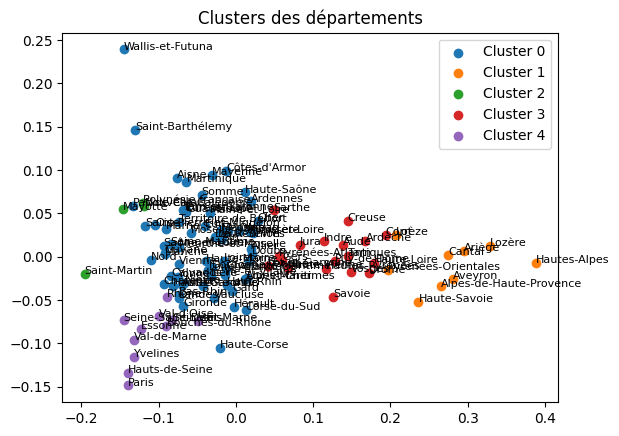

In [19]:
plt.figure()

for c in range(5):
    subset = df_pca[df_pca['cluster'] == c]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {c}')

    for i, dep in enumerate(subset['dep_nom']):
        plt.text(subset['PC1'].iloc[i], subset['PC2'].iloc[i], dep, fontsize=8)

plt.legend()
plt.title("Clusters des départements")
plt.show()

## Quelques analyses descriptives

In [20]:
total_equipements = data.shape[0]
print(total_equipements)

333609


## Répartition par type d'équipements

In [21]:
equip_types = (
    data['equip_type_famille']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

equip_types.head(10)

equip_type_famille
Divers équipements Sports de nature            12.63
Terrain de grands jeux                         12.49
Court de tennis                                11.56
Boulodrome                                      8.59
Multisports/City-stades                         7.66
Salle multisports                               5.57
Salle non spécialisée                           4.84
Equipement équestre                             4.74
Salle ou terrain spécialisé                     4.58
Terrain extérieur de petits jeux collectifs     4.36
Name: proportion, dtype: float64

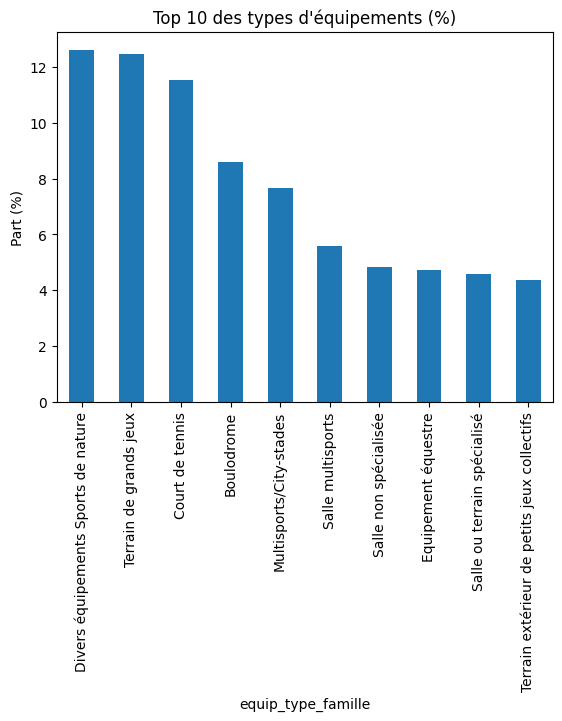

In [22]:
equip_types.head(10).plot(kind='bar')
plt.title("Top 10 des types d'équipements (%)")
plt.ylabel("Part (%)")
plt.show()

In [23]:
equip_dep = (
    data
    .groupby('dep_nom')
    .size()
    .sort_values(ascending=False)
)

equip_dep.head(10)

dep_nom
Nord                    8648
Moselle                 7400
Haute-Garonne           6832
Loire-Atlantique        6543
Pyrénées-Atlantiques    6064
Gironde                 6026
Isère                   5931
Finistère               5910
Bouches-du-Rhône        5874
Pas-de-Calais           5843
dtype: int64

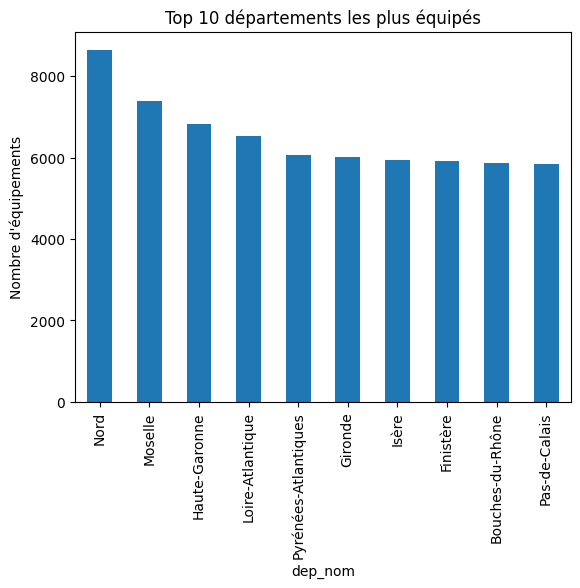

In [24]:
equip_dep.head(10).plot(kind='bar')
plt.title("Top 10 départements les plus équipés")
plt.ylabel("Nombre d'équipements")
plt.show()

In [25]:
equip_dep.describe()

count     107.000000
mean     3115.981308
std      1707.413994
min        16.000000
25%      1881.500000
50%      2922.000000
75%      4046.000000
max      8648.000000
dtype: float64

## Génération d'une carte qui répértorie le nombre d'équipement par famille d'équipement

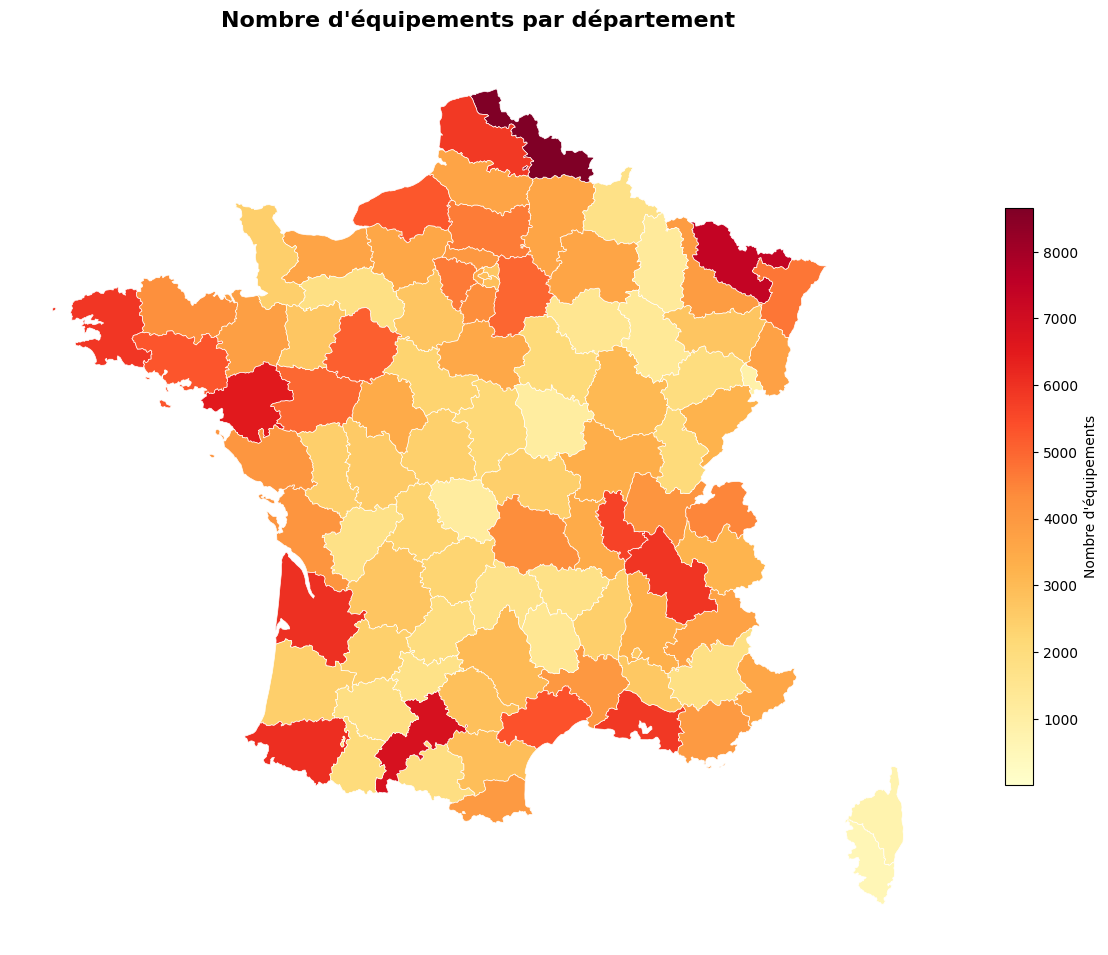

In [26]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests
import io

def plot_carte_nb_equipement_par_famille(famille=None):
    new_data = data.copy()
    if famille is not None:
        new_data = data[data['equip_type_famille'] == famille]
    equip_dep = (
    new_data
    .groupby('dep_nom')
    .size()
    .sort_values(ascending=False)
    )

    # ── 1. Conversion de la Series en DataFrame ───────────────────────────────────
    df = equip_dep.reset_index()
    df.columns = ["departement", "valeur"]

    # ── 2. Téléchargement du GeoJSON ──────────────────────────────────────────────
    url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson"
    response = requests.get(url)
    gdf = gpd.read_file(io.BytesIO(response.content))

    # ── 3. Fusion ─────────────────────────────────────────────────────────────────
    gdf = gdf.merge(df, left_on="nom", right_on="departement", how="left")

    # ── 4. Carte ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    gdf.plot(
        column="valeur",
        ax=ax,
        cmap="YlOrRd",
        legend=True,
        legend_kwds={
            "label": "Nombre d'équipements",
            "orientation": "vertical",
            "shrink": 0.6,
        },
        missing_kwds={
            "color": "#e0e0e0",
            "label": "Données manquantes"
        },
        edgecolor="white",
        linewidth=0.5,
        vmin=df["valeur"].min(),
        vmax=df["valeur"].max()
    )

    ax.set_title("Nombre d'équipements par département", fontsize=16, fontweight="bold", pad=15)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_carte_nb_equipement_par_famille()


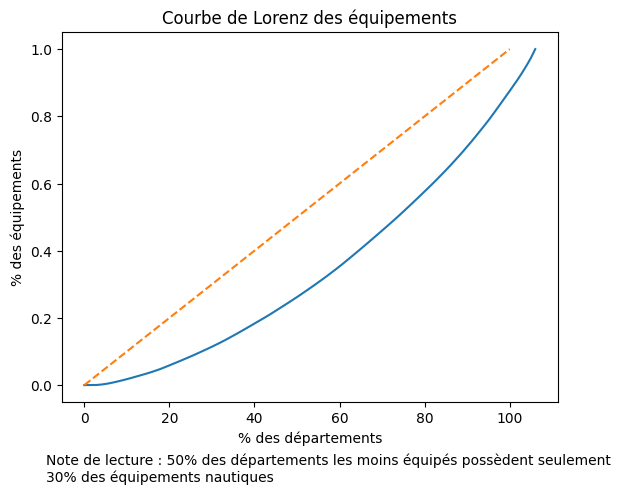

In [42]:
import numpy as np

values = equip_dep.values
values_sorted = np.sort(values)

cum_values = np.cumsum(values_sorted)
cum_values = cum_values / cum_values[-1]

plt.plot(cum_values)
plt.plot([0,100], [0,1], linestyle='--')
plt.xlabel("% des départements")
plt.ylabel("% des équipements")
plt.figtext(0.1, -0.05, 
            "Note de lecture : 50% des départements les moins équipés possèdent seulement 30% des équipements nautiques",
            wrap=True)
plt.title("Courbe de Lorenz des équipements")
plt.show()